# TRRUST Human Clustering

In [1]:
import os, io, time, json, requests, warnings
import numpy as np
import pandas as pd
import warnings
from io import StringIO
from scipy import sparse
from scipy.sparse import diags, csr_matrix
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.plotting import figure, output_file, save
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category20
from matplotlib import colors as mpl_colors
warnings.filterwarnings('ignore')
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

/Users/kayla/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


ModuleNotFoundError: No module named 'bokeh'

## Loading TRRUST Human dataset (Target, Direction, PMID)

In [ ]:
def load_trrust_raw(species='human', local_path='trrust_rawdata.human.tsv', auto_download=True):
    if species != 'human':
        raise ValueError("Only Human")
    if os.path.exists(local_path):
        df = pd.read_csv(local_path, sep='\t', header=None)
    else:
        if not auto_download:
            raise FileNotFoundError(f"Can't fing {local_path}, will auto download.")
        url = "https://www.grnpedia.org/trrust/downloads/trrust_rawdata.human.tsv"
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text), sep='\t', header=None)
        df.to_csv(local_path, sep='\t', header=False, index=False)
        print(f"Download dataset to {local_path}.")
    df.columns = ['tf', 'target', 'direction', 'pmid']
    df['tf'] = df['tf'].astype(str).str.strip()
    df['target'] = df['target'].astype(str).str.strip()
    df['direction'] = df['direction'].astype(str).str.lower().str.strip()
    return df

## Build signed hypergraph

In [ ]:
def build_hypergraph_from_trrust(df, split_pos_neg=True):
    """
    Each TF is a hyperedge.
    split_pos_neg=True: seperate into TF(+), TF(-), sign=+1/-1
    return:
      H: csr_matrix [n_nodes, n_hyperedges]
      signs: np.array [n_hyperedges] in {+1,-1}
      node_list: all targets
      edge_names: TF or TF(+)/TF(-)
    """
    positive = {'activation', 'activator', 'upregulation', 'positive'}
    negative = {'repression', 'repressor', 'downregulation', 'negative'}

    def dir_to_sign(d):
        if d in positive: return +1
        if d in negative: return -1
        return None

    df = df.copy()
    df['sign'] = df['direction'].apply(dir_to_sign)
    df = df.dropna(subset=['sign'])

    # all targets
    node_list = sorted(df['target'].unique().tolist())
    node_index = {g: i for i, g in enumerate(node_list)}

    hyperedges = []
    edge_names = []
    signs = []

    if split_pos_neg:
        for tf, g in df.groupby('tf'):
            for sgn, g2 in g.groupby('sign'):
                targets = sorted(g2['target'].unique().tolist())
                if len(targets) < 1:
                    continue
                hyperedges.append([node_index[t] for t in targets if t in node_index])
                edge_names.append(f"{tf}({ '+' if sgn > 0 else '-' })")
                signs.append(int(sgn))
    else:
        # into one edge
        for tf, g in df.groupby('tf'):
            targets = sorted(g['target'].unique().tolist())
            if len(targets) < 1:
                continue
            s = +1 if g['sign'].sum() >= 0 else -1
            hyperedges.append([node_index[t] for t in targets if t in node_index])
            edge_names.append(tf)
            signs.append(int(s))

    # build H
    rows, cols = [], []
    for j, edge in enumerate(hyperedges):
        for i in edge:
            rows.append(i); cols.append(j)
    H = csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(node_list), len(hyperedges)), dtype=float)
    return H, np.asarray(signs, dtype=float), node_list, edge_names

## ASHD

In [ ]:
class ASHD:
    def __init__(self, embedding_dim=64, n_iter=40, alpha=0.1, random_state=42, variant='full'):
        self.embedding_dim = embedding_dim
        self.n_iter = n_iter
        self.alpha = alpha
        self.variant = variant
        self.eps = 1e-10
        self.rs = np.random.RandomState(random_state)

    def fit(self, H, initial_signs):
        n_nodes, n_edges = H.shape
        # first x
        X = self.rs.normal(0, 0.05, (n_nodes, self.embedding_dim))
        X = X / (np.linalg.norm(X, axis=1, keepdims=True) + self.eps)

        W = initial_signs.astype(float).copy() if self.variant != 'no_signed' else np.ones(n_edges)

        for t in range(self.n_iter):
            de = np.array(H.sum(axis=0)).ravel() + self.eps
            De_inv = diags(1.0 / de)

            dv = np.array(H.dot(np.abs(W))).ravel() + self.eps
            Dv_inv = diags(1.0 / dv)

            W_diag = diags(W)
            # diffusion operator
            P = Dv_inv @ H @ W_diag @ De_inv @ H.T
            X_new = P @ X
            X = X_new / (np.linalg.norm(X_new, axis=1, keepdims=True) + self.eps)

            # adaptive weight
            if self.variant == 'full' and t % 5 == 0:
                # cos
                for j in range(n_edges):
                    idx = H.getcol(j).indices
                    if len(idx) > 1:
                        Xi = X[idx]
                        # similarity
                        s = float(np.mean((Xi @ Xi.T))) 
                        W[j] = float(np.clip(W[j] + self.alpha * np.sign(W[j]) * s, -1.0, 1.0))

        self.embeddings = X
        return X

## t-SNE picture

In [ ]:
def plot_node_scatter_tsne(X, labels, out_png="ashd_tsne_trrust_human.png", title="ASHD Node Embeddings (t-SNE) - TRRUST Human"):
    tsne = TSNE(n_components=2, random_state=42, init='pca')
    coords = tsne.fit_transform(X)
    df = pd.DataFrame({'x': coords[:,0], 'y': coords[:,1], 'cluster': labels})
    plt.figure(figsize=(10, 8)); sns.set_style("whitegrid")
    ax = sns.scatterplot(data=df, x='x', y='y', hue='cluster', palette='tab20', s=10, alpha=0.7, edgecolor=None)
    ax.set_title(title)
    ax.legend(title="Cluster", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout(); plt.savefig(out_png, dpi=300, bbox_inches='tight'); plt.show()
    return df

## Clustering (Base on K-means)

In [ ]:
def build_term_preprocessed_library(df_trrust, split_pos_neg=True, n_clusters=20, random_state=42,
                                    out_csv="TRRUST_human_preprocessed_library.csv"):
    """
    CSV with term, genes, x, y, cluster
    - term: TF 或 TF(+)/TF(-)
    - genes: targets
    - x, y: 2D (t-SNE）
    - cluster: KMeans label
    """
    # term → genes
    positive = {'activation', 'activator', 'upregulation', 'positive'}
    negative = {'repression', 'repressor', 'downregulation', 'negative'}
    def dir_to_sign(d):
        if d in positive: return '+'
        if d in negative: return '-'
        return None
    df = df_trrust.copy()
    df['sgn'] = df['direction'].apply(lambda d: dir_to_sign(d.lower().strip()))
    df = df.dropna(subset=['sgn'])

    rows = []
    if split_pos_neg:
        for (tf, s), g in df.groupby(['tf','sgn']):
            genes = sorted(g['target'].unique().tolist())
            if len(genes) == 0: continue
            rows.append({'term': f"{tf}({s})", 'genes': " ".join(genes)})
    else:
        for tf, g in df.groupby('tf'):
            genes = sorted(g['target'].unique().tolist())
            if len(genes) == 0: continue
            rows.append({'term': tf, 'genes': " ".join(genes)})
    lib = pd.DataFrame(rows)

    # TF-IDF
    corpus = lib['genes'].tolist()
    vec = TfidfVectorizer(token_pattern=r"[^ ]+")
    tfidf = vec.fit_transform(corpus)  # [T, G]

    # 2D
    if HAS_UMAP:
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=random_state)
        coords = reducer.fit_transform(tfidf)
    else:
        coords = TSNE(n_components=2, random_state=random_state, init='pca').fit_transform(tfidf.toarray())

    # cluster
    k = min(max(2, n_clusters), max(2, tfidf.shape[0]//50) if tfidf.shape[0] > 200 else n_clusters)
    labels = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit_predict(tfidf)

    lib['x'] = coords[:,0]; lib['y'] = coords[:,1]; lib['cluster'] = labels.astype(str)
    lib.to_csv(out_csv, index=False)
    return lib

In [ ]:
def run_trrust_human_pipeline(
    trrust_path='trrust_rawdata.human.tsv',
    split_pos_neg=True,
    n_node_clusters=15,
    term_layout_csv="TRRUST_human_preprocessed_library.csv",
    out_dir="Trrust_outputs",
    enrichment_library_name="TRRUST_Transcription_Factors_2019",
    plot_top_k_clusters=5
):
    os.makedirs(out_dir, exist_ok=True)

    # TRRUST Human
    df_trrust = load_trrust_raw('human', local_path=trrust_path, auto_download=True)

    # Build sighed hypergraph
    H, signs, node_list, edge_names = build_hypergraph_from_trrust(df_trrust, split_pos_neg=split_pos_neg)
    # print(f"Vertices: {H.shape[0]}, Edges: {H.shape[1]}")

    # ASHD
    model = ASHD(embedding_dim=64, n_iter=40, alpha=0.1, variant='full', random_state=42)
    X = model.fit(H, signs)

    # KMeans clustering & t-SNE 
    kmeans = KMeans(n_clusters=n_node_clusters, n_init=20, random_state=42)
    node_labels = kmeans.fit_predict(X)
    sil = silhouette_score(X, node_labels)
    print(f"Silhouette Score={sil:.4f}")

    nodes_csv = os.path.join(out_dir, "ashd_clusters_trrust_human.csv")
    pd.DataFrame({'Gene': node_list, 'Cluster': node_labels}).to_csv(nodes_csv, index=False)
    print(f"Save clustring results to: {nodes_csv}")

    tsne_png = os.path.join(out_dir, "ashd_tsne_trrust_human.png")
    plot_node_scatter_tsne(X, node_labels, out_png=tsne_png)

    return {
        "embeddings": X,
        "node_labels": node_labels,
        "node_list": node_list,
        "term_layout_df": term_layout_df,
        "outputs_dir": out_dir
    }



Silhouette Score=0.4181
Save clustring results to: Trrust_outputs/ashd_clusters_trrust_human.csv


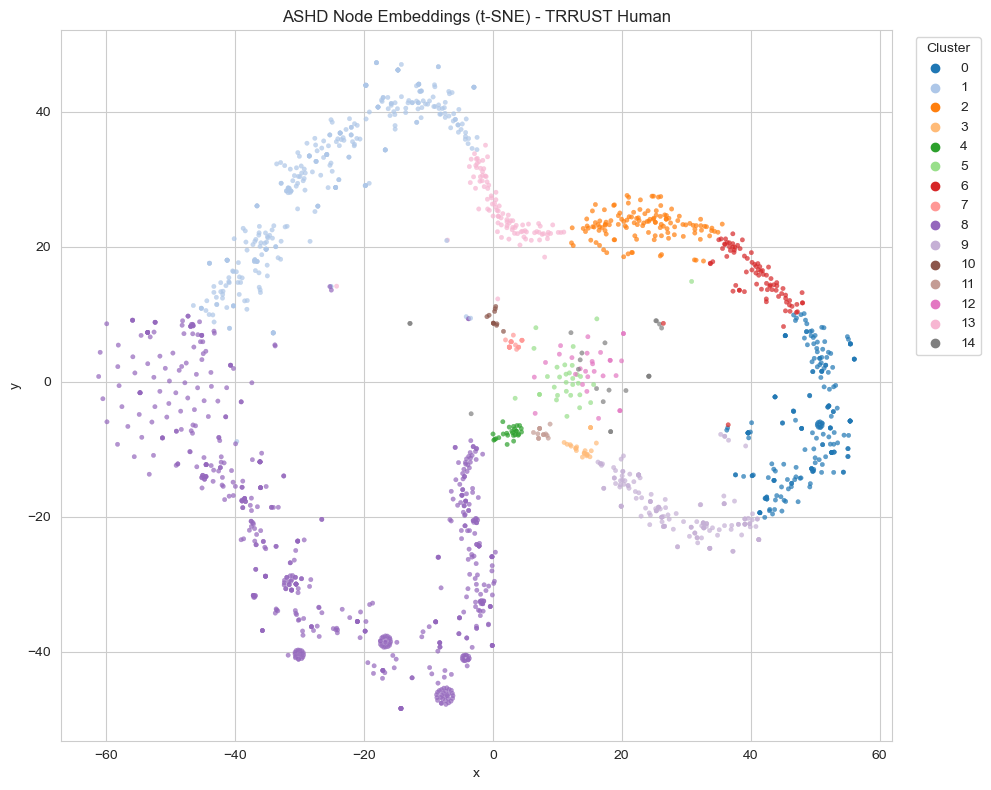

In [ ]:
if __name__ == "__main__":
    run_trrust_human_pipeline(
        trrust_path='trrust_rawdata.human.tsv',   
        split_pos_neg=True,                       
        n_node_clusters=15,
        term_layout_csv="TRRUST_human_preprocessed_library.csv", 
        out_dir="Trrust_outputs",
        plot_top_k_clusters=5
    )

## Clusters' size

In [ ]:
import pandas as pd

df = pd.read_csv("Trrust_outputs/ashd_clusters_trrust_human.csv") 
sizes = df['Cluster'].value_counts().sort_index()
print(sizes)

for cid, sub in df.groupby('Cluster'):
    sub['Gene'].to_csv(f"Trrust_outputs/cluster_{cid}_genes.txt", index=False, header=False)

Cluster
0     204
1     328
2     127
3      21
4      26
5      31
6      80
7      19
8     575
9     144
10     11
11     13
12     28
13     96
14     21
Name: count, dtype: int64
